# pct_ladder Strategy Backtester
Configure parameters below, then **Run All** (`Kernel → Restart & Run All`).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from decimal import Decimal
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Imports OK')

Imports OK


## ⚙️ Configuration

In [2]:
# START_DATE  = '2022-01-01'
# END_DATE    = '2026-01-01'
START_DATE  = '2026-01-01'
END_DATE    = '2026-03-29'
INTERVAL    = '1m'

INITIAL_CASH      = 35_000
INITIAL_ETH       = 5.0
INITIAL_ETH_COST  = 3_000

UPPER_PCT   = 0.4
LOWER_PCT   = 0.4
BUY_QUOTE   = 3200
SELL_QUOTE  = 3200
QTY_STEP    = 1e-6
MIN_QTY     = 1e-6

REBALANCE_THRESHOLD_STEPS = 2
REBALANCE_TARGET_STEPS    = 3

# Compounding: resize buy_quote each interval to keep it at the same % of equity.
# None = disabled | 'daily' | 'weekly' | 'monthly'
COMPOUND_INTERVAL = 'daily'

QUOTE_RESERVE        = 500
USE_INVENTORY_BUFFER = True

SYMBOL       = 'ETHUSDC'
FETCH_SYMBOL = 'ETHUSDT'
DATA_SOURCE  = 'binance'
CACHE_DIR    = 'cache'

# Config comparison uses a coarser interval for speed (1h = ~35k candles vs 2.1M for 1m)
COMPARE_INTERVAL = '1h'   # '1m' for full accuracy | '1h' for fast comparison

## 📥 Fetch Historical Data

In [3]:
from backtest.fetch_data import fetch_klines, dt_to_ms

df_candles = fetch_klines(
    symbol=FETCH_SYMBOL, interval=INTERVAL,
    start_ms=dt_to_ms(START_DATE), end_ms=dt_to_ms(END_DATE),
    cache_dir=CACHE_DIR, source=DATA_SOURCE,
)
candles = df_candles.to_dict('records')
days    = (pd.Timestamp(END_DATE) - pd.Timestamp(START_DATE)).days
print(f'Loaded {len(df_candles):,} candles  |  {df_candles["ts"].iloc[0]}  ->  {df_candles["ts"].iloc[-1]}')
df_candles.tail(3)

[fetch_data] Fetching ETHUSDT 1m from BINANCE (~125,280 candles, ~126 requests)...
[fetch_data]   39.9% — 50,000 candles fetched...
[fetch_data]   79.8% — 100,000 candles fetched...
[fetch_data] Done — 125,281 candles. Cached to cache/binance_ETHUSDT_1m_1767225600000_1774742400000.parquet
Loaded 125,281 candles  |  2026-01-01 00:00:00+00:00  ->  2026-03-29 00:00:00+00:00


,ts,open,high,low,close
125278,2026-03-28 23:58:00+00:00,1994.21,1994.23,1994.20,1994.22
125279,2026-03-28 23:59:00+00:00,1994.22,1995.23,1994.22,1994.74
125280,2026-03-29 00:00:00+00:00,1994.74,1994.81,1993.89,1994.60


## 🔁 Run Backtest — Flat vs Compounding

In [4]:
from backtest.engine import BacktestEngine
from strategies.pct_ladder.strategy import create_strategy

def make_engine(compound_interval=None):
    scfg = dict(
        symbols=[SYMBOL], upper_pct=UPPER_PCT, lower_pct=LOWER_PCT,
        sizing_mode='fixed_quote', buy_quote=BUY_QUOTE, sell_quote=SELL_QUOTE,
        qty_step=QTY_STEP, min_qty=MIN_QTY,
        rebalance_threshold_steps=REBALANCE_THRESHOLD_STEPS,
        rebalance_target_steps=REBALANCE_TARGET_STEPS,
    )
    return BacktestEngine(
        strategy=create_strategy(scfg), symbol=SYMBOL,
        initial_cash=Decimal(str(INITIAL_CASH)), initial_eth=Decimal(str(INITIAL_ETH)),
        initial_eth_cost=Decimal(str(INITIAL_ETH_COST)), quote_reserve=Decimal(str(QUOTE_RESERVE)),
        use_inventory_buffer=USE_INVENTORY_BUFFER, compound_interval=compound_interval,
    )

print('Running WITHOUT compounding...')
eng_flat = make_engine(None);  s_flat = eng_flat.run(candles);  print('Done.')
print(f'Running WITH compounding ({COMPOUND_INTERVAL})...')
eng_comp = make_engine(COMPOUND_INTERVAL);  s_comp = eng_comp.run(candles);  print('Done.')

Running WITHOUT compounding...
Done.
Running WITH compounding (daily)...
Done.


## 📊 Summary — Flat vs Compounding

In [5]:
# ── Summary: Flat vs Compounding ──────────────────────────────────────────────
def summary_table():
    rows = []
    final_price = float(df_candles['close'].iloc[-1])
    years = days / 365

    for label, eng, s in [
        ('Flat',                          eng_flat, s_flat),
        (f'Compound ({COMPOUND_INTERVAL})', eng_comp, s_comp),
    ]:
        ss        = eng.state.symbol_states[SYMBOL]
        init_eq   = s['initial_equity']
        usdt      = float(eng.state.cash)
        eth_qty   = float(ss.traded_qty)
        eth_val   = eth_qty * final_price
        total     = usdt + eth_val
        total_pnl = total - init_eq

        # Formula PnL: sum(cycles × buy_quote × pct%)  — sell legs only, excl rebalance
        df_t  = pd.DataFrame(eng.trades)
        sells = df_t[(df_t['side'] == 'SELL') & (~df_t['reason'].str.startswith('rebalance_'))]
        cycles_pnl = float((sells['buy_quote'] * sells['upper_pct'] / 100).sum())

        # Final step size from last recorded trade
        last_nr    = df_t[~df_t['reason'].str.startswith('rebalance_')]
        step_size  = float(last_nr['buy_quote'].iloc[-1]) if not last_nr.empty else BUY_QUOTE

        rows.append({
            'Mode':                  label,
            'Period':                f'{START_DATE}  →  {END_DATE}  ({days:,}d)',
            'Initial Equity':        f'${init_eq:,.2f}',
            'Final USDT':            f'${usdt:,.2f}',
            'Final ETH Qty':         f'{eth_qty:.4f}',
            'Final ETH Value':       f'${eth_val:,.2f}',
            'Final Total':           f'${total:,.2f}',
            'Total PnL':             f'${total_pnl:,.2f}  ({total_pnl/init_eq*100:.1f}%)',
            'Cycles PnL (formula)':  f'${cycles_pnl:,.2f}',
            'Annualised Return':     f'{((total/init_eq)**(1/years)-1)*100:.1f}%',
            'Max Drawdown':          f"{s['max_drawdown_pct']:.2f}%",
            'Total Cycles':          f"{s['cycles']:,}",
            'Cycles / Day':          f"{s['cycles']/days:.2f}",
            'Final Step Size':       f'${step_size:,.2f}',
            'Pct':                   f'{UPPER_PCT}%',
            'Rebalance Trades':      f"{s['rebalance_trades']:,}",
        })

    df = pd.DataFrame(rows).set_index('Mode').T
    return df.style.set_properties(**{'text-align': 'left'})

summary_table()


Mode,Flat,Compound (daily)
Period,2026-01-01 → 2026-03-29 (87d),2026-01-01 → 2026-03-29 (87d)
Initial Equity,"$49,859.35","$49,859.35"
Final USDT,"$9,600.00","$48,233.04"
Final ETH Qty,27.2813,10.3636
Final ETH Value,"$54,415.30","$20,671.30"
Final Total,"$64,015.30","$68,904.34"
Total PnL,"$14,155.95 (28.4%)","$19,044.99 (38.2%)"
Cycles PnL (formula),"$43,801.60","$50,019.88"
Annualised Return,185.3%,288.6%
Max Drawdown,16.90%,14.23%


## 📅 Yearly Breakdown

In [6]:
# ── Helper functions — run this cell once before any breakdown section ───────

def get_monthly(engine):
    df_t = pd.DataFrame(engine.trades)
    df_t['ts']    = pd.to_datetime(df_t['ts'], utc=True, errors='coerce')
    df_t['month'] = df_t['ts'].dt.to_period('M')
    lad  = df_t[~df_t['reason'].str.startswith('rebalance_')]
    m_b  = lad[lad['side']=='BUY'].groupby('month').size().rename('buys')
    m_s  = lad[lad['side']=='SELL'].groupby('month').size().rename('sells')
    lp   = lad[lad['side']=='SELL'].sort_values('ts').groupby('month')['realized_pnl_cumulative'].last()
    m_p  = lp.diff().fillna(lp.iloc[0]).rename('realized_pnl').round(2)
    sells = lad[lad['side']=='SELL']
    m_formula = sells.groupby('month').apply(
        lambda g: (g['buy_quote'] * g['upper_pct'] / 100).sum()
    ).rename('formula_pnl').round(2)
    df_m = pd.concat([m_b, m_s, m_p, m_formula], axis=1).fillna(0)
    df_m['cycles'] = df_m[['buys','sells']].min(axis=1).astype(int)
    df_m['buys']   = df_m['buys'].astype(int)
    df_m['sells']  = df_m['sells'].astype(int)
    df_m = df_m.reset_index()
    df_m['month'] = df_m['month'].astype(str)
    return df_m[['month','buys','sells','cycles','formula_pnl','realized_pnl']]


def period_snapshot(engine, df_candles, freq='M'):
    df_t = pd.DataFrame(engine.trades)
    if df_t.empty:
        return pd.DataFrame()
    df_t['ts']     = pd.to_datetime(df_t['ts'], utc=True, errors='coerce')
    df_t['period'] = df_t['ts'].dt.to_period(freq)
    eop      = df_t.groupby('period').last()[['cash_after','eth_after','buy_quote','upper_pct']]
    sells    = df_t[(df_t['side']=='SELL') & (~df_t['reason'].str.startswith('rebalance_'))]
    cycles_s = sells.groupby('period').size().rename('cycles')
    formula_s = sells.groupby('period').apply(
        lambda g: (g['buy_quote'] * g['upper_pct'] / 100).sum()
    ).rename('cycles_pnl').round(2)
    offset = {'D':'1D', 'M':'1ME', 'Y':'1YE'}.get(freq, '1ME')
    px = df_candles.set_index('ts')['close'].resample(offset).last().dropna()
    px.index = px.index.to_period(freq)
    px.index.name = 'period'
    px.name = 'price'
    df = pd.concat([eop, cycles_s, formula_s, px], axis=1).dropna(subset=['cash_after'])
    df['cycles']     = df['cycles'].fillna(0).astype(int)
    df['cycles_pnl'] = df['cycles_pnl'].fillna(0)
    df['price']      = df['price'].ffill()
    df['eth_value']  = (df['eth_after'] * df['price']).round(2)
    df['total']      = (df['cash_after'] + df['eth_value']).round(2)
    df['cash_after'] = df['cash_after'].round(2)
    df['eth_after']  = df['eth_after'].round(6)
    df = df.reset_index()
    df['period'] = df['period'].astype(str)
    return df[['period','cash_after','eth_after','eth_value','total','cycles','buy_quote','upper_pct','cycles_pnl']]\
             .rename(columns={'cash_after':'usdt','eth_after':'eth_qty',
                              'buy_quote':'step_size','upper_pct':'pct%'})


def to_yearly(df_m, df_snap=None):
    df = df_m.copy()
    df['year'] = df['month'].str[:4]
    agg = (df.groupby('year').agg(buys=('buys','sum'), sells=('sells','sum'),
             cycles=('cycles','sum'), cycles_pnl=('formula_pnl','sum'))
            .reset_index()
            .assign(cycles_pnl=lambda d: d['cycles_pnl'].round(2)))
    if df_snap is not None and not df_snap.empty:
        snap = df_snap.copy()
        snap['year'] = snap['period'].str[:4]
        yr_end = snap.groupby('year').last()[['total','step_size']].reset_index()
        yr_end['total_pnl'] = yr_end['total'].diff().round(2)
        yr_end.loc[yr_end.index[0], 'total_pnl'] = round(
            yr_end['total'].iloc[0] - snap['total'].iloc[0] + snap['cycles_pnl'].iloc[0], 2)
        avg_q = snap.groupby('year')['step_size'].mean().round(2).reset_index()\
                    .rename(columns={'step_size':'avg_buy_quote'})
        yr_end = yr_end[['year','total_pnl']].merge(avg_q, on='year', how='left')
        agg = agg.merge(yr_end, on='year', how='left')
    return agg[['year','buys','sells','cycles','avg_buy_quote','cycles_pnl','total_pnl']]


print('Helper functions defined: get_monthly, period_snapshot, to_yearly')


Helper functions defined: get_monthly, period_snapshot, to_yearly


In [7]:
df_m_flat, df_m_comp = get_monthly(eng_flat), get_monthly(eng_comp)
df_snap_flat = period_snapshot(eng_flat, df_candles, freq='M')
df_snap_comp = period_snapshot(eng_comp, df_candles, freq='M')
df_y_flat = to_yearly(df_m_flat, df_snap_flat)
df_y_comp = to_yearly(df_m_comp, df_snap_comp)

fmt = {'cycles_pnl':'${:,.2f}','total_pnl':'${:,.2f}','avg_buy_quote':'${:,.2f}'}
print('Yearly — Flat')
display(df_y_flat.style.format(fmt).hide(axis='index'))
print(f'\nYearly — Compounding ({COMPOUND_INTERVAL})')
display(df_y_comp.style.format(fmt).hide(axis='index'))


Yearly — Flat


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,3575,3422,3422,"$3,200.00","$43,801.60","$24,372.97"



Yearly — Compounding (daily)


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,3575,3422,3422,"$3,852.47","$50,019.88","$28,735.49"


## 📅 Monthly Breakdown

In [8]:
fmt = {'realized_pnl': '${:,.2f}', 'formula_pnl': '${:,.2f}'}
print('Monthly — Flat')
display(df_m_flat.style.format(fmt).hide(axis='index'))
print(f'Monthly — Compounding ({COMPOUND_INTERVAL})')
display(df_m_comp.style.format(fmt).hide(axis='index'))


Monthly — Flat


month,buys,sells,cycles,formula_pnl,realized_pnl
2026-01,764,724,724,"$9,267.20","$3,170.37"
2026-02,1833,1746,1746,"$22,348.80","$8,793.76"
2026-03,978,952,952,"$12,185.60","$9,127.44"


Monthly — Compounding (daily)


month,buys,sells,cycles,formula_pnl,realized_pnl
2026-01,764,724,724,"$9,591.69","$3,116.54"
2026-02,1833,1746,1746,"$24,356.01","$10,922.18"
2026-03,978,952,952,"$16,072.18","$7,171.68"


## 📋 Period Snapshot — Formula PnL
USDT balance · ETH holding · total equity · cycles · formula PnL (`cycles × buy_quote × pct%`).
This is the cleanest view of strategy performance.

In [9]:
# Monthly snapshot — flat run
df_snap_flat = period_snapshot(eng_flat, df_candles, freq='M')
df_snap_comp = period_snapshot(eng_comp, df_candles, freq='M')

fmt = {'usdt':'${:,.2f}','eth_value':'${:,.2f}','total':'${:,.2f}',
       'step_size':'${:,.2f}','cycles_pnl':'${:,.2f}'}
print('=== Monthly Snapshot — Flat ===')
display(df_snap_flat.style.format(fmt).hide(axis='index'))
print(f'\n=== Monthly Snapshot — Compounding ({COMPOUND_INTERVAL}) ===')
display(df_snap_comp.style.format(fmt).hide(axis='index'))


=== Monthly Snapshot — Flat ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$25,600.00",9.506528,"$23,309.53","$48,909.53",724,"$3,200.00",0.400000,"$9,267.20"
2026-02,"$35,199.99",12.058743,"$23,689.52","$58,889.51",1746,"$3,200.00",0.400000,"$22,348.80"
2026-03,"$9,600.00",27.281311,"$54,415.30","$64,015.30",952,"$3,200.00",0.400000,"$12,185.60"



=== Monthly Snapshot — Compounding (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$26,307.52",9.565050,"$23,453.02","$49,760.54",724,"$3,288.44",0.400000,"$9,591.69"
2026-02,"$46,067.90",8.117742,"$15,947.39","$62,015.29",1746,"$3,859.09",0.400000,"$24,356.01"
2026-03,"$48,233.04",10.363632,"$20,671.30","$68,904.34",952,"$4,409.88",0.400000,"$16,072.18"


In [10]:
# Yearly snapshot
df_snap_y_flat = period_snapshot(eng_flat, df_candles, freq='Y')
df_snap_y_comp = period_snapshot(eng_comp, df_candles, freq='Y')

fmt = {'usdt':'${:,.2f}','eth_value':'${:,.2f}','total':'${:,.2f}',
       'step_size':'${:,.2f}','cycles_pnl':'${:,.2f}'}
print('=== Yearly Snapshot — Flat ===')
display(df_snap_y_flat.style.format(fmt).hide(axis='index'))
print(f'\n=== Yearly Snapshot — Compounding ({COMPOUND_INTERVAL}) ===')
display(df_snap_y_comp.style.format(fmt).hide(axis='index'))


=== Yearly Snapshot — Flat ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$9,600.00",27.281311,"$54,415.30","$64,015.30",3422,"$3,200.00",0.400000,"$43,801.60"



=== Yearly Snapshot — Compounding (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$48,233.04",10.363632,"$20,671.30","$68,904.34",3422,"$4,409.88",0.400000,"$50,019.88"


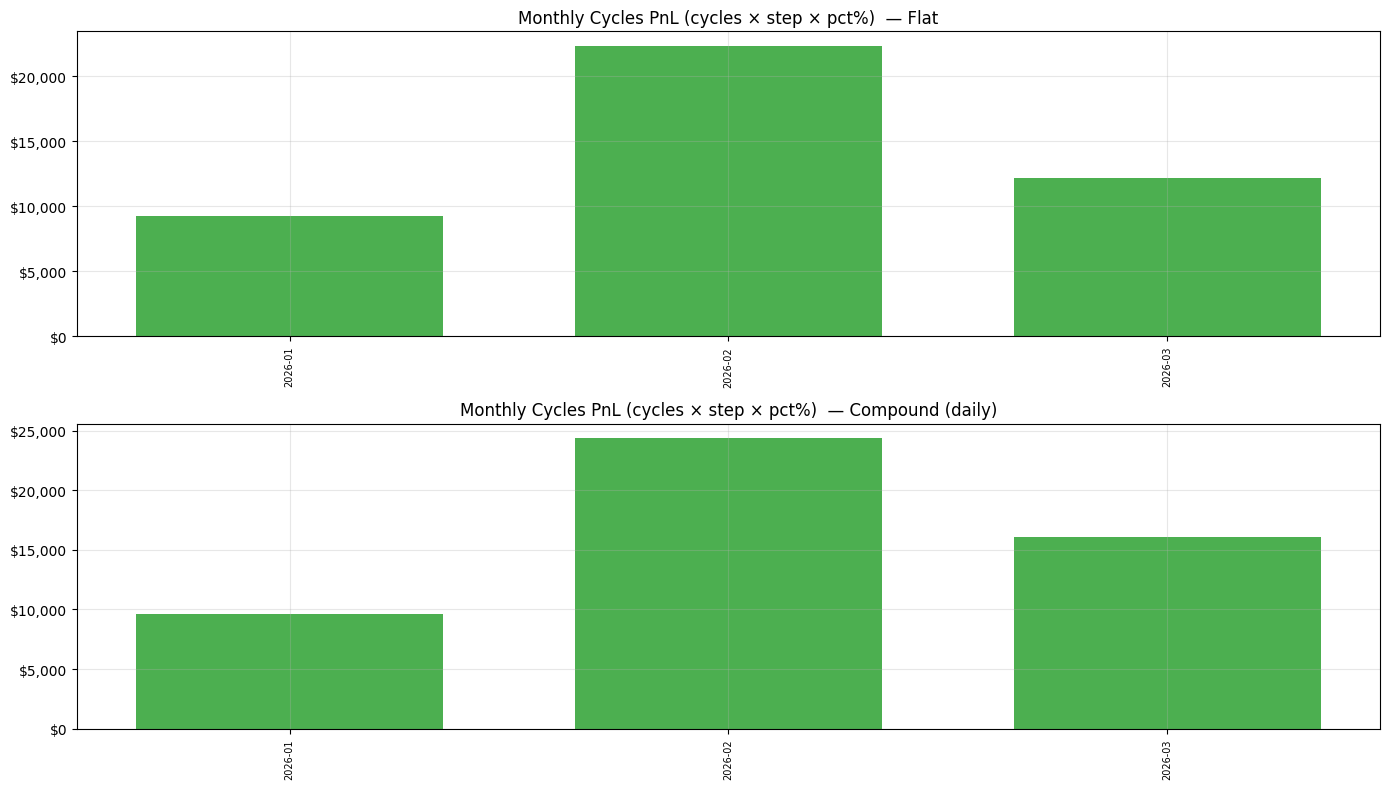

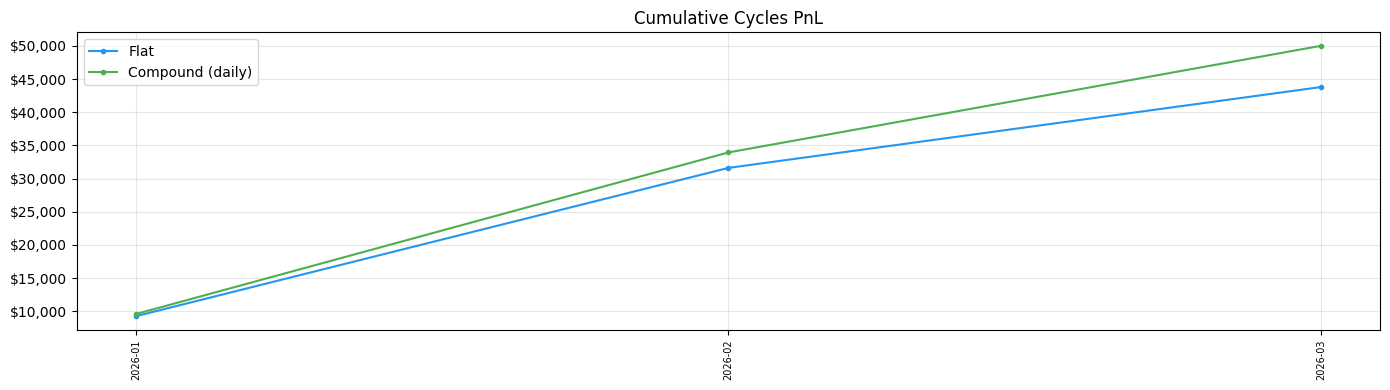

In [11]:
# Cycles PnL chart — flat vs compounding
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
for ax, df_s, title in [
    (ax1, df_snap_flat, 'Flat'),
    (ax2, df_snap_comp, f'Compound ({COMPOUND_INTERVAL})'),
]:
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in df_s['cycles_pnl']]
    ax.bar(df_s['period'], df_s['cycles_pnl'], color=colors, width=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(f'Monthly Cycles PnL (cycles × step × pct%)  — {title}')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

# Cumulative cycles PnL
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_snap_flat['period'], df_snap_flat['cycles_pnl'].cumsum(),
        marker='o', ms=3, lw=1.5, color='#2196F3', label='Flat')
ax.plot(df_snap_comp['period'], df_snap_comp['cycles_pnl'].cumsum(),
        marker='o', ms=3, lw=1.5, color='#4CAF50', label=f'Compound ({COMPOUND_INTERVAL})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Cumulative Cycles PnL')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


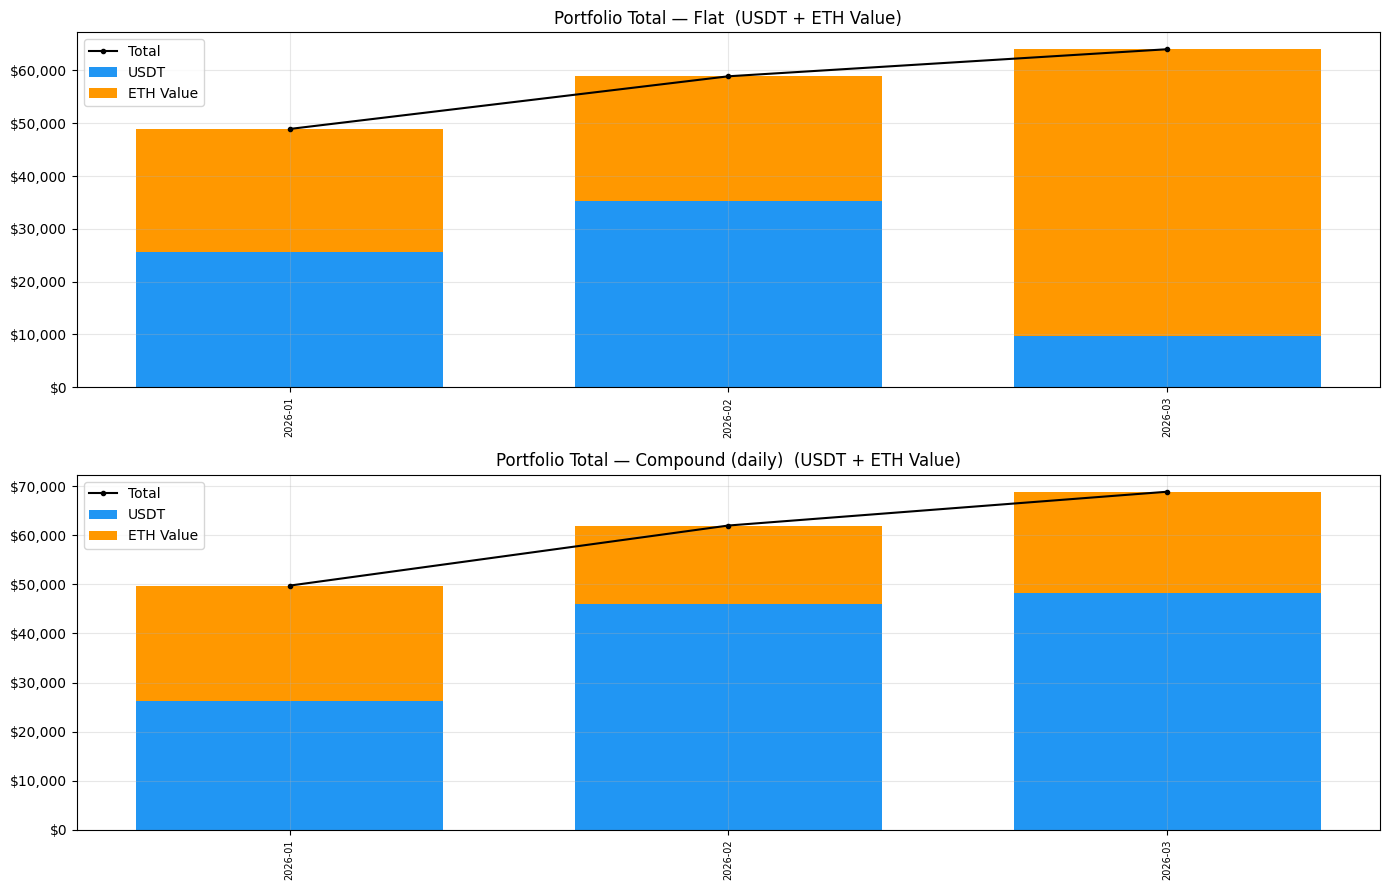

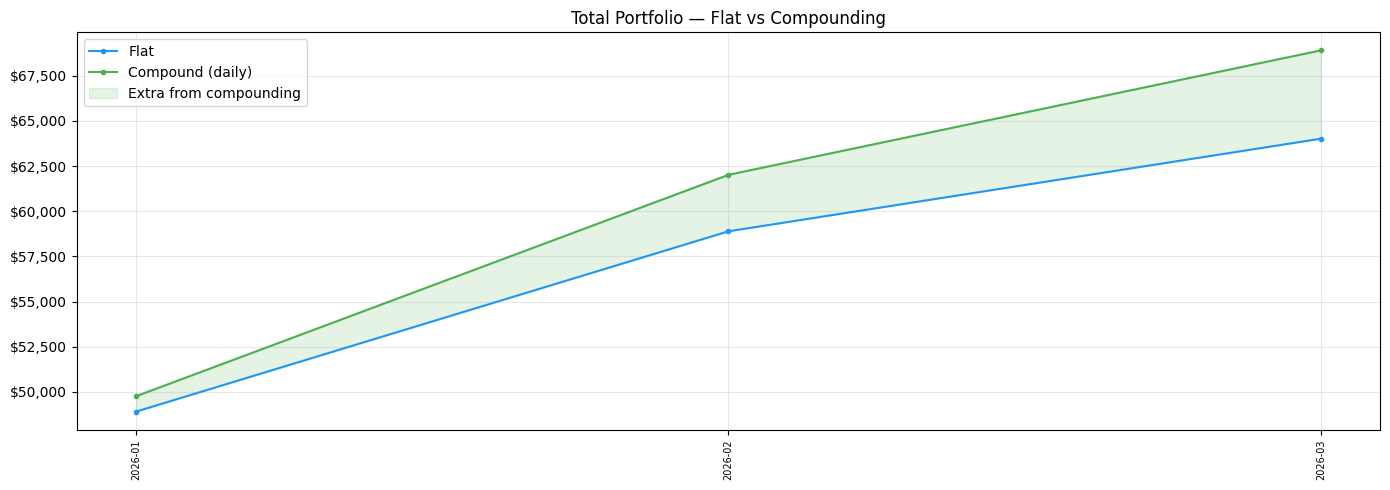

In [12]:
# Total equity over time — stacked USDT + ETH value, flat vs compounding
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

for ax, df_s, title in [
    (ax1, df_snap_flat, 'Flat'),
    (ax2, df_snap_comp, f'Compound ({COMPOUND_INTERVAL})'),
]:
    months = df_s['period']
    x      = range(len(months))

    # Stacked bar: USDT (bottom) + ETH value (top)
    ax.bar(x, df_s['usdt'],      color='#2196F3', width=0.7, label='USDT')
    ax.bar(x, df_s['eth_value'], color='#FF9800', width=0.7,
           bottom=df_s['usdt'], label='ETH Value')

    # Total line on top
    ax.plot(x, df_s['total'], color='black', linewidth=1.5,
            marker='o', markersize=3, label='Total')

    ax.set_xticks(list(x))
    ax.set_xticklabels(months, rotation=90, fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.set_title(f'Portfolio Total — {title}  (USDT + ETH Value)')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Flat vs Compounding total on same chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_snap_flat['period'], df_snap_flat['total'],
        marker='o', ms=3, lw=1.5, color='#2196F3', label='Flat')
ax.plot(df_snap_comp['period'], df_snap_comp['total'],
        marker='o', ms=3, lw=1.5, color='#4CAF50', label=f'Compound ({COMPOUND_INTERVAL})')
ax.fill_between(df_snap_comp['period'],
                df_snap_comp['total'], df_snap_flat['total'],
                alpha=0.15, color='#4CAF50', label='Extra from compounding')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('Total Portfolio — Flat vs Compounding')
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


## 📈 Equity Curve — Flat vs Compounding

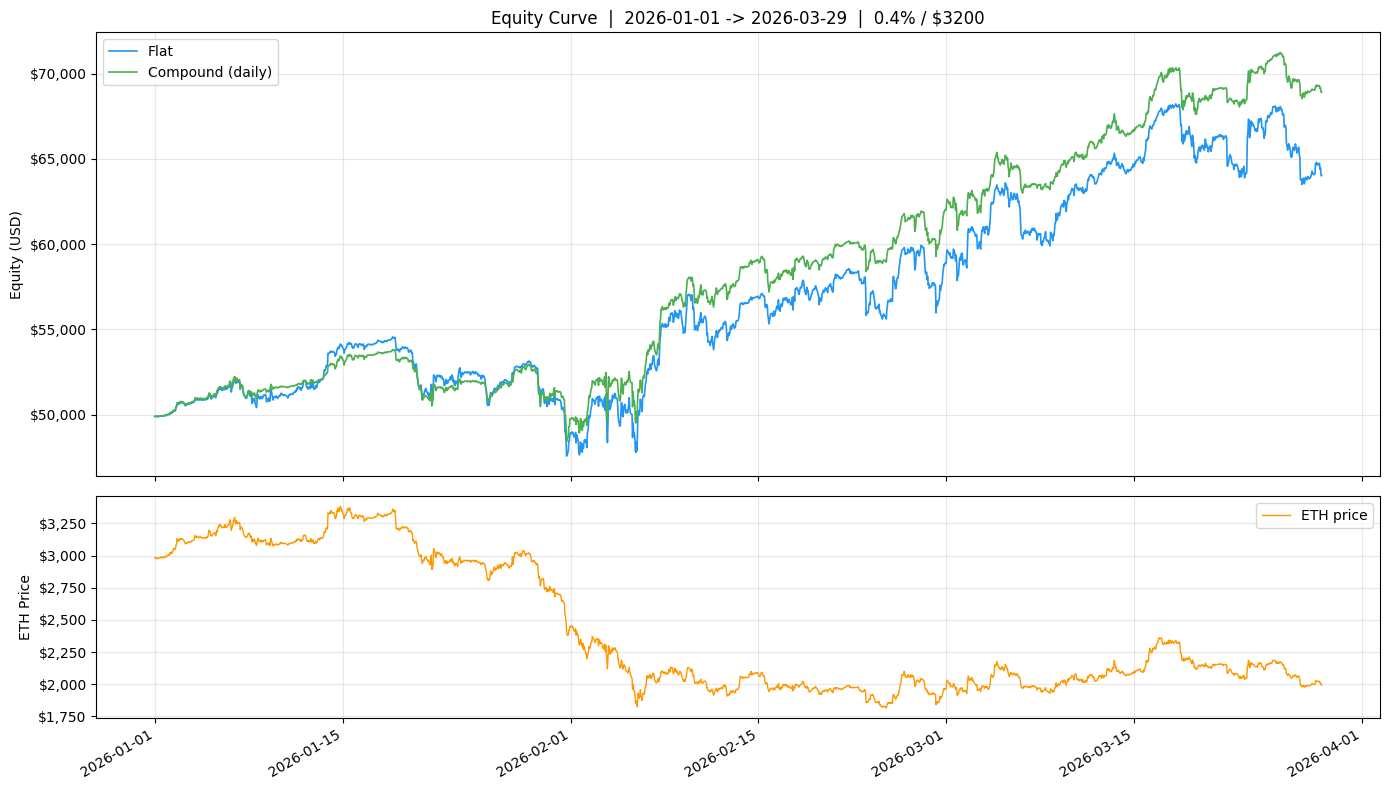

In [13]:
def eq_df(engine):
    ts  = pd.to_datetime([t for t,_ in engine.equity_curve], utc=True)
    val = [v for _,v in engine.equity_curve]
    return pd.DataFrame({'equity': val}, index=ts).resample('1h').last().dropna()

df_eq_flat = eq_df(eng_flat)
df_eq_comp = eq_df(eng_comp)
df_px = df_candles.set_index('ts')['close'].resample('1h').last().dropna()

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8), sharex=True, gridspec_kw={'height_ratios':[2,1]})
ax1.plot(df_eq_flat.index, df_eq_flat['equity'], color='#2196F3', lw=1.2, label='Flat')
ax1.plot(df_eq_comp.index, df_eq_comp['equity'], color='#4CAF50', lw=1.2, label=f'Compound ({COMPOUND_INTERVAL})')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax1.set_ylabel('Equity (USD)'); ax1.legend()
ax1.set_title(f'Equity Curve  |  {START_DATE} -> {END_DATE}  |  {UPPER_PCT}% / ${BUY_QUOTE}')
ax2.plot(df_px.index, df_px.values, color='#FF9800', lw=1, label='ETH price')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.set_ylabel('ETH Price'); ax2.legend()
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 💰 Monthly PnL — Flat vs Compounding

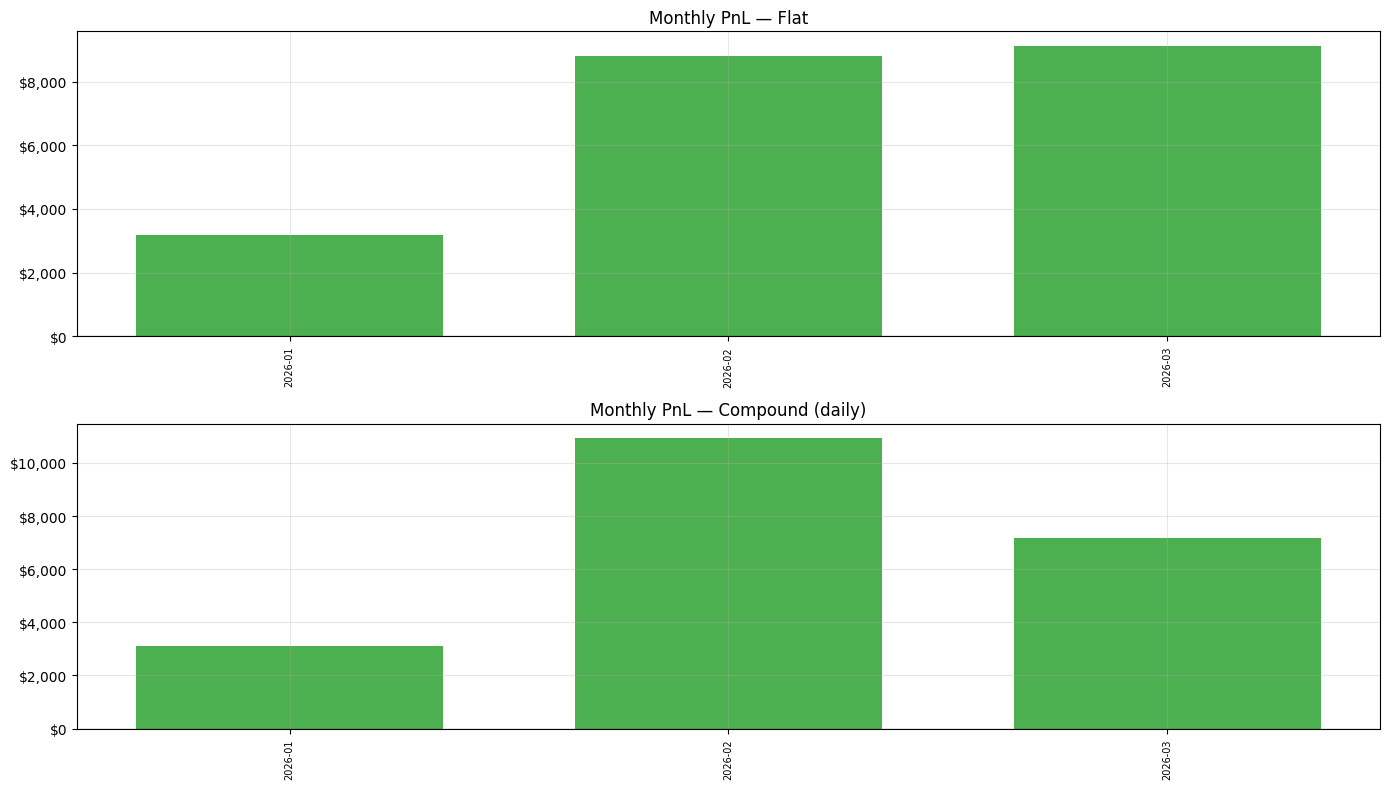

In [14]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,8))
for ax, df_m, title in [(ax1, df_m_flat, 'Flat'), (ax2, df_m_comp, f'Compound ({COMPOUND_INTERVAL})')]:
    colors = ['#4CAF50' if v>=0 else '#F44336' for v in df_m['realized_pnl']]
    ax.bar(df_m['month'], df_m['realized_pnl'], color=colors, width=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.set_title(f'Monthly PnL — {title}')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout(); plt.show()

## 📈 Cumulative PnL — Flat vs Compounding

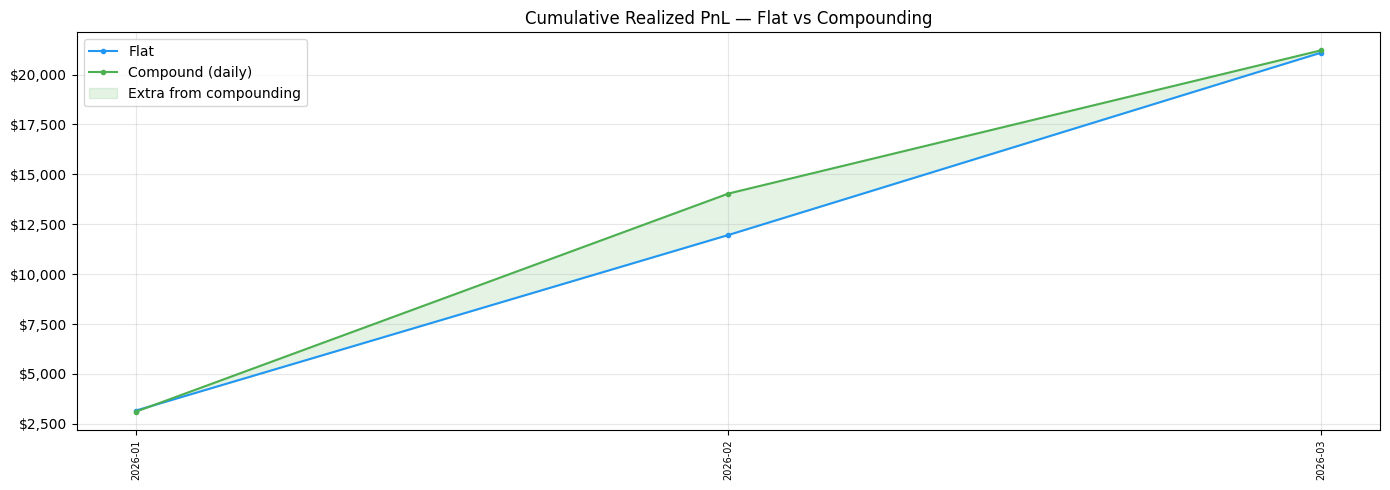

In [15]:
cum_flat = df_m_flat['realized_pnl'].cumsum().values
cum_comp = df_m_comp['realized_pnl'].cumsum().values
months   = df_m_flat['month'].values

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(months, cum_flat, marker='o', ms=3, lw=1.5, color='#2196F3', label='Flat')
ax.plot(months[:len(cum_comp)], cum_comp, marker='o', ms=3, lw=1.5, color='#4CAF50', label=f'Compound ({COMPOUND_INTERVAL})')
ax.fill_between(months[:len(cum_comp)], cum_comp, cum_flat[:len(cum_comp)], alpha=0.15, color='#4CAF50', label='Extra from compounding')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Cumulative Realized PnL — Flat vs Compounding'); ax.legend()
plt.xticks(rotation=90, fontsize=7); plt.tight_layout(); plt.show()

## 📐 Step Size History (Compounding)

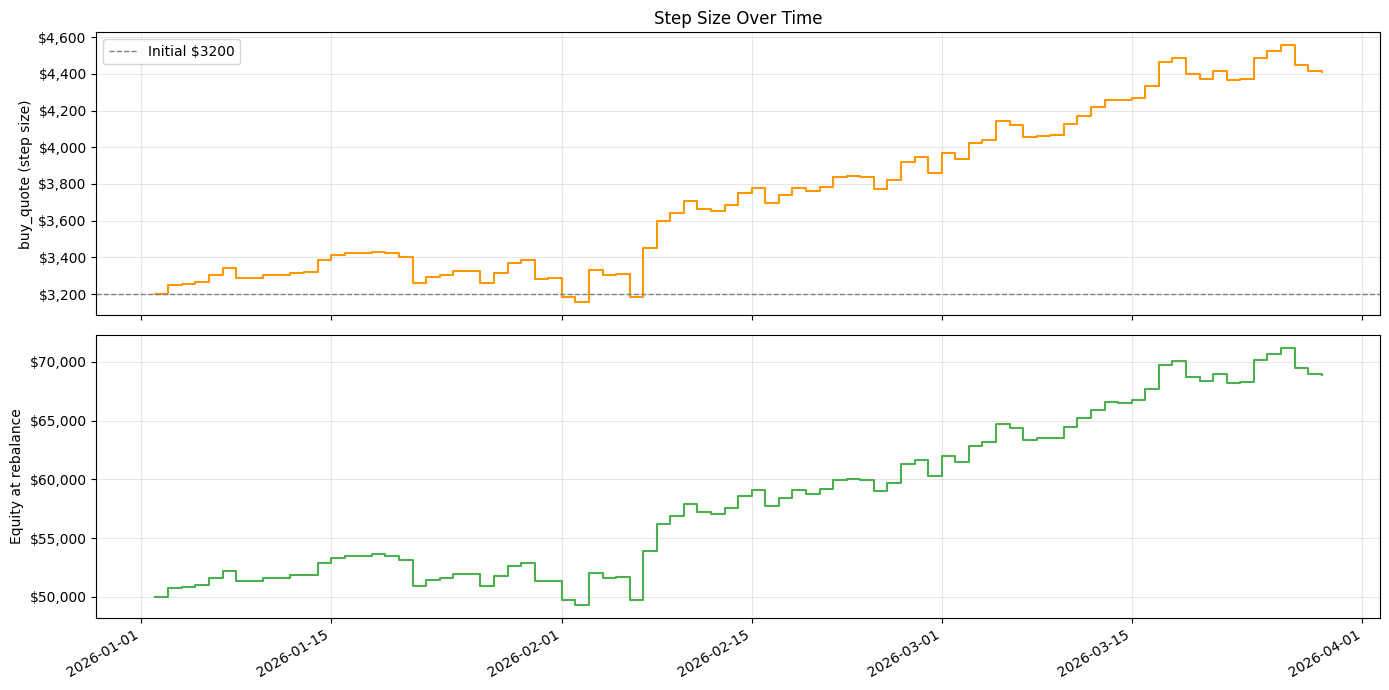

Step size: $3,200  ->  $4,409.88  (87 adjustments)


ts,equity,old_quote,new_quote,eth_before,eth_after,eth_target
2026-03-18 00:00:00+00:00,"$70,122.33","$4,464.15","$4,487.83",9.0752,9.0752,9.0752
2026-03-19 00:00:00+00:00,"$68,703.09","$4,487.83","$4,397.00",9.3564,9.3564,9.3564
2026-03-20 00:00:00+00:00,"$68,344.63","$4,397.00","$4,374.06",9.5863,9.5863,9.5863
2026-03-21 00:00:00+00:00,"$69,004.48","$4,374.06","$4,416.29",9.6435,9.6435,9.6435
2026-03-22 00:00:00+00:00,"$68,191.68","$4,416.29","$4,364.27",9.8414,9.8414,9.8414
2026-03-23 00:00:00+00:00,"$68,276.50","$4,364.27","$4,369.70",9.9662,9.9662,9.9662
2026-03-24 00:00:00+00:00,"$70,125.69","$4,369.70","$4,488.04",9.7618,9.7618,9.7618
2026-03-25 00:00:00+00:00,"$70,667.86","$4,488.04","$4,522.74",7.9311,9.8375,9.8375
2026-03-26 00:00:00+00:00,"$71,186.69","$4,522.74","$4,555.95",9.8473,9.8473,9.8473
2026-03-27 00:00:00+00:00,"$69,501.70","$4,555.95","$4,448.11",10.1275,10.1275,10.1275


In [16]:
if eng_comp.compound_log:
    df_cl = pd.DataFrame(eng_comp.compound_log)
    df_cl['ts'] = pd.to_datetime(df_cl['ts'], utc=True, errors='coerce')

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,7), sharex=True)
    ax1.step(df_cl['ts'], df_cl['new_quote'], where='post', color='#FF9800', lw=1.5)
    ax1.axhline(BUY_QUOTE, color='gray', ls='--', lw=1, label=f'Initial ${BUY_QUOTE}')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax1.set_ylabel('buy_quote (step size)'); ax1.set_title('Step Size Over Time'); ax1.legend()
    ax2.step(df_cl['ts'], df_cl['equity'], where='post', color='#4CAF50', lw=1.5)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax2.set_ylabel('Equity at rebalance')
    fig.autofmt_xdate(); plt.tight_layout(); plt.show()

    print(f'Step size: ${BUY_QUOTE:,}  ->  ${df_cl["new_quote"].iloc[-1]:,.2f}  ({len(df_cl)} adjustments)')
    display(df_cl[['ts','equity','old_quote','new_quote','eth_before','eth_after','eth_target']].tail(12)
            .style.format({'equity':'${:,.2f}','old_quote':'${:,.2f}','new_quote':'${:,.2f}',
                           'eth_before':'{:.4f}','eth_after':'{:.4f}','eth_target':'{:.4f}'}).hide(axis='index'))
else:
    print('Compounding disabled.')

## 📉 Drawdown — Flat vs Compounding

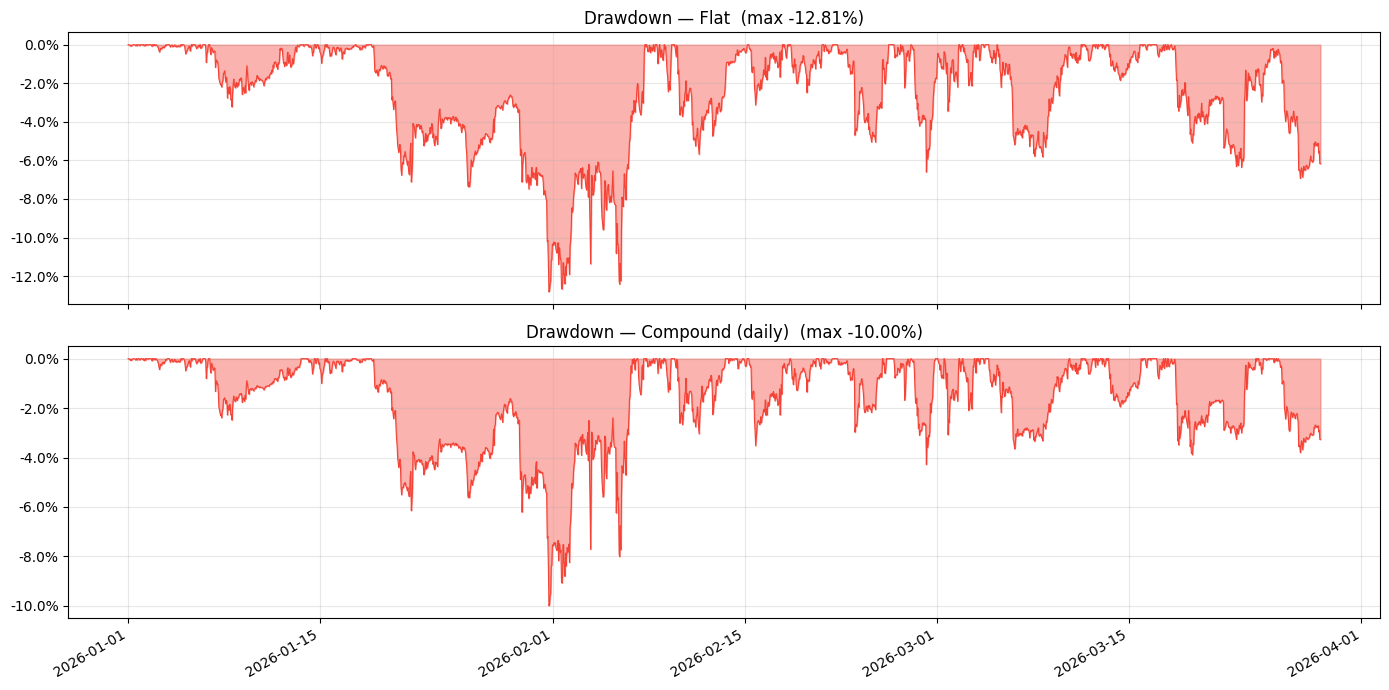

In [17]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,7), sharex=True)
for ax, df_eq, label in [(ax1, df_eq_flat, 'Flat'), (ax2, df_eq_comp, f'Compound ({COMPOUND_INTERVAL})')]:
    peak = df_eq['equity'].cummax()
    dd   = (df_eq['equity'] - peak) / peak * 100
    ax.fill_between(dd.index, dd.values, 0, color='#F44336', alpha=0.4)
    ax.plot(dd.index, dd.values, color='#F44336', lw=0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}%'))
    ax.set_title(f'Drawdown — {label}  (max {dd.min():.2f}%)')
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 🔄 Config Comparison — Flat vs Compounding

In [13]:
COMPARE_CONFIGS = [
    dict(label='0.4% / $1400', upper_pct=0.4, lower_pct=0.4, buy_quote=1400, sell_quote=1400),
    dict(label='0.6% / $1500', upper_pct=0.6, lower_pct=0.6, buy_quote=1500, sell_quote=1500),
    dict(label='0.5% / $1000', upper_pct=0.5, lower_pct=0.5, buy_quote=1000, sell_quote=1000),
    dict(label='1.0% / $2000', upper_pct=1.0, lower_pct=1.0, buy_quote=2000, sell_quote=2000),
]

# Fetch comparison candles (coarser interval = faster)
print(f'Fetching {COMPARE_INTERVAL} candles for comparison...')
df_cmp_candles = fetch_klines(
    symbol=FETCH_SYMBOL, interval=COMPARE_INTERVAL,
    start_ms=dt_to_ms(START_DATE), end_ms=dt_to_ms(END_DATE),
    cache_dir=CACHE_DIR, source=DATA_SOURCE,
)
cmp_candles = df_cmp_candles.to_dict('records')
print(f'Comparison candles: {len(cmp_candles):,}')

results = []
for cfg in COMPARE_CONFIGS:
    for compound in [None, COMPOUND_INTERVAL]:
        scfg = dict(symbols=[SYMBOL], sizing_mode='fixed_quote', qty_step=QTY_STEP, min_qty=MIN_QTY,
                    rebalance_threshold_steps=REBALANCE_THRESHOLD_STEPS,
                    rebalance_target_steps=REBALANCE_TARGET_STEPS,
                    **{k:v for k,v in cfg.items() if k!='label'})
        eng = BacktestEngine(
            strategy=create_strategy(scfg), symbol=SYMBOL,
            initial_cash=Decimal(str(INITIAL_CASH)), initial_eth=Decimal(str(INITIAL_ETH)),
            initial_eth_cost=Decimal(str(INITIAL_ETH_COST)), quote_reserve=Decimal(str(QUOTE_RESERVE)),
            use_inventory_buffer=USE_INVENTORY_BUFFER, compound_interval=compound,
        )
        s = eng.run(cmp_candles)
        mode = f'Compound ({COMPOUND_INTERVAL})' if compound else 'Flat'
        results.append({
            'Config': cfg['label'], 'Mode': mode,
            'Realized PnL':  round(s['realized_pnl'], 2),
            'Final Equity':  round(s['final_equity'], 2),
            'Annualised%':   round(((s['final_equity']/s['initial_equity'])**(365/days)-1)*100, 1) if days else 0,
            'Cycles':        s['cycles'],
            'Avg PnL/Cycle': round(s['realized_pnl']/s['cycles'], 2) if s['cycles'] else 0,
            'Max DD%':       s['max_drawdown_pct'],
        })
        print(f"  {cfg['label']:20s}  [{mode:25s}]  cycles={s['cycles']:,}  pnl=${s['realized_pnl']:,.0f}")

df_cmp = pd.DataFrame(results)
df_cmp.style\
    .format({'Formula PnL':'${:,.2f}','Realized PnL':'${:,.2f}','Final Equity':'${:,.2f}',
             'Annualised%':'{:.1f}%','Avg PnL/Cycle':'${:.2f}','Max DD%':'{:.2f}%'})\
    .highlight_max(subset=['Realized PnL','Annualised%'], color='#c8e6c9')\
    .highlight_min(subset=['Max DD%'], color='#c8e6c9')\
    .hide(axis='index')

Fetching 1h candles for comparison...
[fetch_data] Loading cached data from cache/binance_ETHUSDT_1h_1640995200000_1767225600000.parquet
Comparison candles: 35,064
  0.4% / $1400          [Flat                     ]  cycles=20,375  pnl=$232,136
  0.4% / $1400          [Compound (biweekly)      ]  cycles=20,375  pnl=$11,075,782
  0.6% / $1500          [Flat                     ]  cycles=13,549  pnl=$196,046
  0.6% / $1500          [Compound (biweekly)      ]  cycles=13,550  pnl=$3,468,597
  0.5% / $1000          [Flat                     ]  cycles=16,427  pnl=$146,611
  0.5% / $1000          [Compound (biweekly)      ]  cycles=16,433  pnl=$1,275,652
  1.0% / $2000          [Flat                     ]  cycles=6,829  pnl=$175,384
  1.0% / $2000          [Compound (biweekly)      ]  cycles=6,827  pnl=$2,569,155


Config,Mode,Realized PnL,Final Equity,Annualised%,Cycles,Avg PnL/Cycle,Max DD%
0.4% / $1400,Flat,"$232,135.82","$269,640.49",57.6%,20375,$11.39,30.59%
0.4% / $1400,Compound (biweekly),"$11,075,782.46","$10,845,138.88",296.7%,20375,$543.60,19.86%
0.6% / $1500,Flat,"$196,045.91","$230,858.34",51.6%,13549,$14.47,33.92%
0.6% / $1500,Compound (biweekly),"$3,468,596.85","$3,333,040.78",195.4%,13550,$255.99,25.51%
0.5% / $1000,Flat,"$146,610.77","$185,864.38",43.6%,16427,$8.92,39.05%
0.5% / $1000,Compound (biweekly),"$1,275,651.56","$1,281,442.75",132.7%,16433,$77.63,34.67%
1.0% / $2000,Flat,"$175,383.53","$210,388.17",48.2%,6829,$25.68,35.54%
1.0% / $2000,Compound (biweekly),"$2,569,155.36","$2,491,041.38",174.7%,6827,$376.32,24.89%


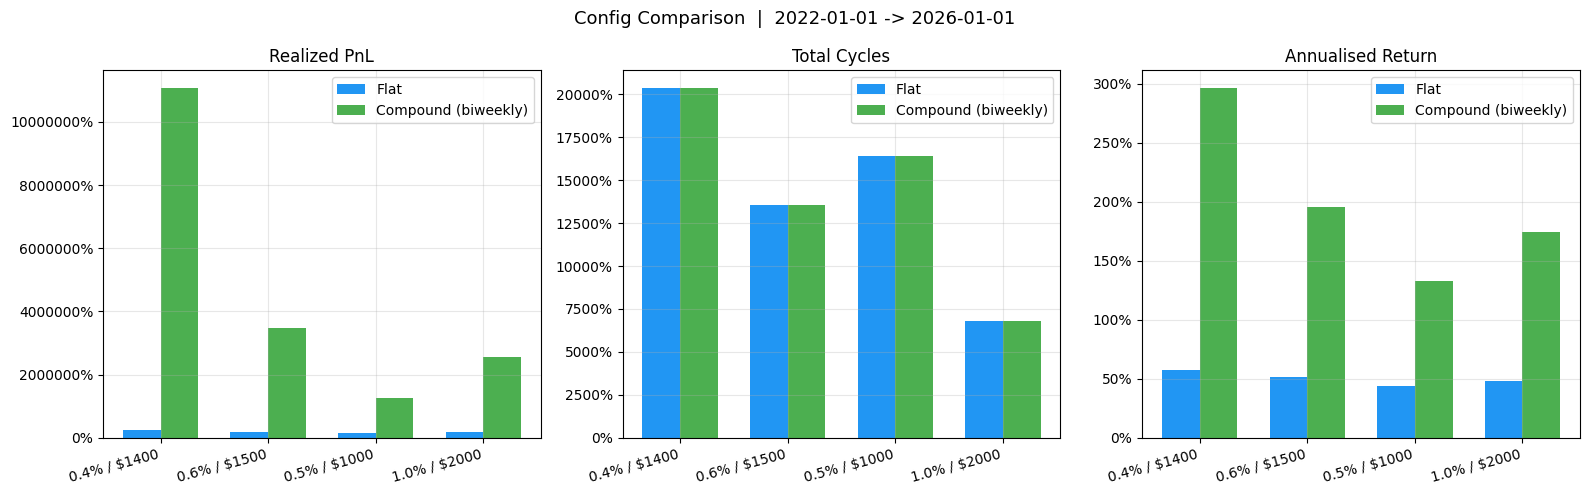

In [14]:
configs  = df_cmp['Config'].unique()
df_f     = df_cmp[df_cmp['Mode']=='Flat']
df_c     = df_cmp[df_cmp['Mode']!='Flat']
x, w     = range(len(configs)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title, fmt_fn in [
    (axes[0], 'Realized PnL',  'Realized PnL',      lambda v: f'${v:,.0f}'),
    (axes[1], 'Cycles',        'Total Cycles',       lambda v: f'{v:,.0f}'),
    (axes[2], 'Annualised%',   'Annualised Return',  lambda v: f'{v:.0f}%'),
]:
    ax.bar([i-w/2 for i in x], df_f[col], w, label='Flat',                        color='#2196F3')
    ax.bar([i+w/2 for i in x], df_c[col], w, label=f'Compound ({COMPOUND_INTERVAL})', color='#4CAF50')
    ax.set_xticks(list(x)); ax.set_xticklabels(configs, rotation=15, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: fmt_fn(v)))
    ax.set_title(title); ax.legend()

plt.suptitle(f'Config Comparison  |  {START_DATE} -> {END_DATE}', fontsize=13)
plt.tight_layout(); plt.show()